In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid

print(tf.__version__)

2.18.1


In [17]:
import pandas as pd
import numpy as np

# for building linear regression models and preparing data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_excel("~/Downloads/credit_data.xls", header=1)

df = df.drop("ID", axis=1)

X = df.drop("default payment next month", axis=1).values

y = df["default payment next month"].values

print(f"the shape of the inputs x is: {X.shape}")

the shape of the inputs x is: (30000, 23)


In [18]:
# splitting dataset into training, cross_validation, and test datasets

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
x_train, x_, y_train, y_ = train_test_split(X, y, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

del x_, y_

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (18000, 23)
the shape of the training set (target) is: (18000,)

the shape of the cross validation set (input) is: (6000, 23)
the shape of the cross validation set (target) is: (6000,)

the shape of the test set (input) is: (6000, 23)
the shape of the test set (target) is: (6000,)


In [37]:
# Initialize the class , scaling features to improve run time of gradient descent
scaler_linear = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
X_train_scaled = scaler_linear.fit_transform(x_train)
X_cv_scaled = scaler_linear.fit_transform(x_cv)
X_test_scaled = scaler_linear.fit_transform(x_test)

# check scaled data
print(f"the data x_train after scaling: {X_train_scaled}")

the data x_train after scaling: [[-1.209408   -1.23386447  1.43765706 ... -0.29278567 -0.28862087
  -0.2843539 ]
 [-0.90179428  0.81046179  0.17673872 ... -0.24610461 -0.2496409
  -0.27498618]
 [ 0.48246748  0.81046179  0.17673872 ...  0.02217736 -0.04761216
   0.17829104]
 ...
 [-0.90179428 -1.23386447  0.17673872 ... -0.2658904  -0.25618116
  -0.25238275]
 [-0.67108398 -1.23386447 -1.08417962 ... -0.22075196  0.99503667
  -0.15906808]
 [ 1.0207915  -1.23386447  0.17673872 ... -0.30874845  0.61046917
  -0.11899838]]


In [48]:
def classification_error(y, yhat):
    m = len(y)
    inaccurate = 0;
    for i in range (m):
        inaccurate += 0 if(y[i]==yhat[i])  else 1
    cerr = inaccurate/m
    return cerr

In [49]:
from sklearn.utils.class_weight import compute_class_weight

layer_1_units = [32, 64, 128, 256, 512]
layer_2_units = [16, 32, 64, 128, 256]
m = len(layer_1_units)
cv_error = np.zeros(m)
train_error = np.zeros(m)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

for i in range(m):
    model = Sequential(
        [
            Dense(layer_1_units[i], activation='relu'),
            Dense(layer_2_units[i], activation='relu'),
            Dense(1, activation='linear')
        ],  name = "my_model" )
    model.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
    model.fit(X_train_scaled, y_train, epochs=100, verbose=0, validation_data=(X_cv_scaled, y_cv), callbacks=[early_stop],  class_weight=class_weight_dict)
    z = model.predict(X_train_scaled, verbose=0)
    yhat = tf.nn.sigmoid(z).numpy()
    yhat_class =  (yhat >= 0.5).astype(int)
    terr = classification_error(y_train, yhat_class)
    train_error[i]= terr
    
    z_cv = model.predict(X_cv_scaled, verbose=0)
    yhat_cv = tf.nn.sigmoid(z_cv).numpy()
    yhat_cv_class =  (yhat_cv >= 0.5).astype(int)
    cerr = classification_error(y_cv, yhat_cv_class)
    cv_error[i] = cerr
print(f"the cv error rate for different models: {cv_error}")
print(f"the train error rate for different models: {train_error}")

the cv error rate for different models: [0.249      0.32033333 0.37716667 0.34216667 0.49133333]
the train error rate for different models: [0.23994444 0.31155556 0.36833333 0.32288889 0.48616667]


In [50]:
lambda_values = [0, 0.001, 0.01, 0.1, 1]
m = len(layer_1_units)
cv_error = np.zeros(m)
train_error = np.zeros(m)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
for i in range(m):
    model = Sequential(
        [
            Dense(32, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(lambda_values[i])),
            Dense(16, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(lambda_values[i])),
            Dense(1, activation='linear')
        ],  name = "my_model" )
    model.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
    model.fit(X_train_scaled, y_train, epochs=100, verbose=0, validation_data=(X_cv_scaled, y_cv), callbacks=[early_stop], class_weight=class_weight_dict)
    z = model.predict(X_train_scaled, verbose=0)
    yhat = tf.nn.sigmoid(z).numpy()
    yhat_class =  (yhat >= 0.5).astype(int)
    terr = classification_error(y_train, yhat_class)
    train_error[i]= terr
    
    z_cv = model.predict(X_cv_scaled, verbose=0)
    yhat_cv = tf.nn.sigmoid(z_cv).numpy()
    yhat_cv_class =  (yhat_cv >= 0.5).astype(int)
    cerr = classification_error(y_cv, yhat_cv_class)
    cv_error[i] = cerr
print(f"the cv error rate for different models: {cv_error}")
print(f"the train error rate for different models: {train_error}")

the cv error rate for different models: [0.3095     0.32       0.3355     0.25366667 0.783     ]
the train error rate for different models: [0.29788889 0.30361111 0.32261111 0.24161111 0.78005556]


In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

model = Sequential(
        [
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(1, activation='linear')
        ],  name = "my_model" )
model.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer = tf.keras.optimizers.Adam(learning_rate=0.001))
model.fit(X_train_scaled, y_train, epochs=100, verbose=0, validation_data=(X_cv_scaled, y_cv), callbacks=[early_stop])


In [58]:
threshold_val = [0.1, 0.2, 0.3, 0.4 , 0.5 , 0.6, 0.7]
m = len(threshold_val)
precision = np.zeros(m)
recall = np.zeros(m)
f1 = np.zeros(m)

z_test = model.predict(X_test_scaled, verbose=0)
yhat_test = tf.nn.sigmoid(z_test).numpy().flatten()

for i in range(m):
    yhat_test_class =  (yhat_test >= threshold_val[i]).astype(int)

    precision[i] = precision_score(y_test, yhat_test_class)
    recall[i] = recall_score(y_test, yhat_test_class)
    f1[i] = f1_score(y_test, yhat_test_class)


print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: [0.25200321 0.35870384 0.56649396 0.68218085 0.72319202 0.71428571
 0.76923077]
Recall: [0.91358025 0.69135802 0.47639797 0.37254902 0.21060276 0.06899056
 0.02904866]
F1 Score: [0.39503847 0.47233937 0.51755424 0.48191639 0.32620922 0.12582781
 0.05598321]


In [59]:
z_test = model.predict(X_test_scaled, verbose=0)

yhat_test = tf.nn.sigmoid(z_test).numpy().flatten()

yhat_test_class =  (yhat_test >= 0.3).astype(int)
    
error_rate = classification_error(y_test, yhat_test_class)

print("error", error_rate)

error 0.20383333333333334


In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, yhat_test)
auc = roc_auc_score(y_test, yhat_test)

print("AUC:", auc)

AUC: 0.7276724583328817


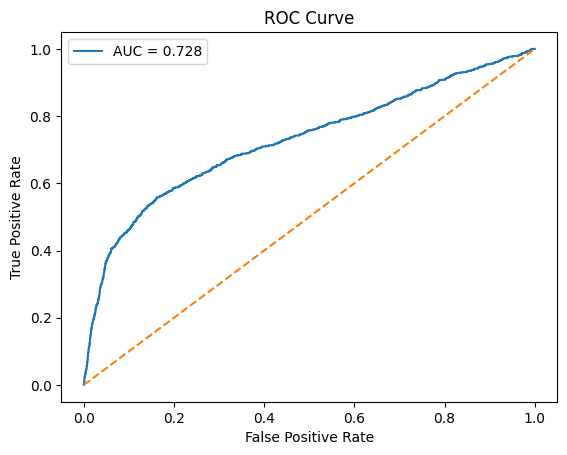

In [61]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()